# Freight Rate Multivariate Regression Analysis

The aim of this project to model and analyze global freight rate movements using oil prices and global trade volume as cost-side and demand-side explanatory variables.

## About the Dataset

This project combines multiple macroeconomic and shipping market datasets to analyze global freight rate movements. The objective is to model maritime freight rates using two key explanatory drivers: oil prices (cost-side factor) and global trade volume (demand-side factor).

The datasets are sourced from publicly available economic and shipping market data providers. Freight rates are represented using the Baltic Dry Index (Capesize)oil prices are represented by Brent crude oil prices, and global demand is approximated using worldwide exports of goods and services.

These datasets span different time frequencies (daily and yearly) and are aligned to a common monthly time scale to enable multivariate regression analysis.

The combined dataset consists of three predictor variables and one target variable:

* Target variable: Freight Rate (Baltic Dry Index – Capesize)

* Predictor variable 1: Oil Price (Brent crude)

* Predictor variable 2: Global Trade Volume (World exports of goods and services)

### Data Sources

| Dataset                     | Source             | Description                                      |
|-----------------------------|--------------------|--------------------------------------------------|
| Baltic Dry Index (Capesize) | Baltic Exchange    | Measures global dry bulk shipping freight rates  |
| Brent Crude Oil Prices      | EIA / Kaggle       | Global benchmark for crude oil prices            |
| Global Trade Volume         | World Bank         | Worldwide exports of goods and services          |


### Data Dictionary

| Feature       | Description                                                  |
|---------------|--------------------------------------------------------------|
| Date          | Monthly time index after resampling and alignment            |
| Freight_Rate  | Baltic Dry Index (Capesize), proxy for global freight rates  |
| Oil_Price     | Brent crude oil price (USD per barrel)                       |
| Trade_Volume  | Global exports of goods and services (USD, World Bank)       |
| Oil_Lag1      | Oil price lagged by 1 month                                  |
| Oil_Lag2      | Oil price lagged by 2 months                                 |

### Target Variable

#### Freight_Rate
This represents global maritime shipping costs. The Baltic Dry Index (Capesize) tracks the cost of transporting raw materials such as iron ore and coal and is widely used as a proxy for global shipping demand.

### Predictor Variables

#### Oil_Price
Represents the cost of bunker fuel used by cargo vessels. Changes in oil prices directly impact shipping operating costs and therefore influence freight rates.

#### Trade_Volume
Represents global demand for shipping. Higher global exports imply increased cargo movement, leading to higher demand for vessels and increased freight rates.

### Models
Baseline:  Freight Rate = α + β₁(Oil Price) + β₂(Trade Volume) + ε

Advanced:  Freight Rate = α + β₁(Oil Price) + β₂(Trade Volume) + β₃(Oil Lag 1M) + β₄(Oil Lag 2M) + ε

In [15]:
# importing the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error


In [7]:
# Load the data set
# ── 1. Load BDI ──────────────────────────────────────────
bdi = pd.read_csv("/Users/lunga_2.0/freight-analysis/data/BDI.csv")

bdi["Date"] = pd.to_datetime(bdi["Date"], format="%b %d, %Y")
bdi = bdi[["Date", "CI"]].rename(columns={"CI": "Freight_Rate"})
bdi = bdi.set_index("Date").sort_index()

# ── 2. Load Oil ──────────────────────────────────────────
oil = pd.read_csv("/Users/lunga_2.0/freight-analysis/data/BrentOilPrices.csv")

oil["Date"] = pd.to_datetime(oil["Date"], format="mixed")
oil = oil.set_index("Date").rename(columns={"Price": "Oil_Price"}).sort_index()

# ── 3. Load Trade (World Bank) ───────────────────────────
trade_raw = pd.read_csv("/Users/lunga_2.0/freight-analysis/data/API_NE.EXP.GNFS.CD_DS2_en_csv_v2_175529.csv", skiprows=4)
world = trade_raw[trade_raw["Country Name"] == "World"]

## Data Processing

To ensure compatibility across datasets:

* Daily freight rates were resampled to monthly averages

* Daily oil prices were resampled to monthly averages

* Yearly trade data was converted to monthly using forward-fill

* All datasets were merged on a monthly time index

* Lagged oil variables were created to capture delayed market response

Final dataset:

- Frequency: Monthly

- Period: Aug 2012 – Jul 2019

- Observations: 84 rows

- Variables: 5 features + target

In [10]:
# Melt the year columns into rows
year_cols = [c for c in trade_raw.columns if c.isdigit()]
world_long = world[year_cols].T.reset_index()
world_long.columns = ["Year", "Trade_Volume"]
world_long["Date"] = pd.to_datetime(world_long["Year"].astype(str))
world_long = world_long.set_index("Date")[["Trade_Volume"]]

# Resample yearly -> monthly (forward fill)
trade_monthly = world_long.resample("ME").ffill()

# ── 4. Merge all on monthly frequency ───────────────────
bdi_monthly = bdi.resample("ME").mean()        # daily → monthly average
oil_monthly  = oil.resample("ME").mean()        # daily → monthly average

df = bdi_monthly.join(oil_monthly).join(trade_monthly).dropna()
df = df.reset_index()

#print(df.shape)
#print(df.head())

        Date  Freight_Rate   Oil_Price  Trade_Volume
0 2012-08-31   1153.954545  113.356087  2.282473e+13
1 2012-09-30   1341.700000  112.863684  2.282473e+13
2 2012-10-31   2104.217391  111.710870  2.282473e+13
3 2012-11-30   2279.636364  109.058571  2.282473e+13
4 2012-12-31   1583.562500  109.494000  2.282473e+13


## Exploration Data Analysis

In the exploratory data analysis, the distributions of the freight rate, oil price, and global trade volume variables are examined, followed by an investigation of the relationships between the explanatory variables and the target variable. Correlation analysis is then performed to evaluate the strength and direction of associations among the variables. Through time-series visualizations and scatter plots, overall trends, co-movements, and potential lagged effects between oil prices and freight rates can be identified. This process helps reveal underlying patterns in the data, assess the suitability of the variables for regression modeling, and generate insights into the economic drivers of global freight rate movements.


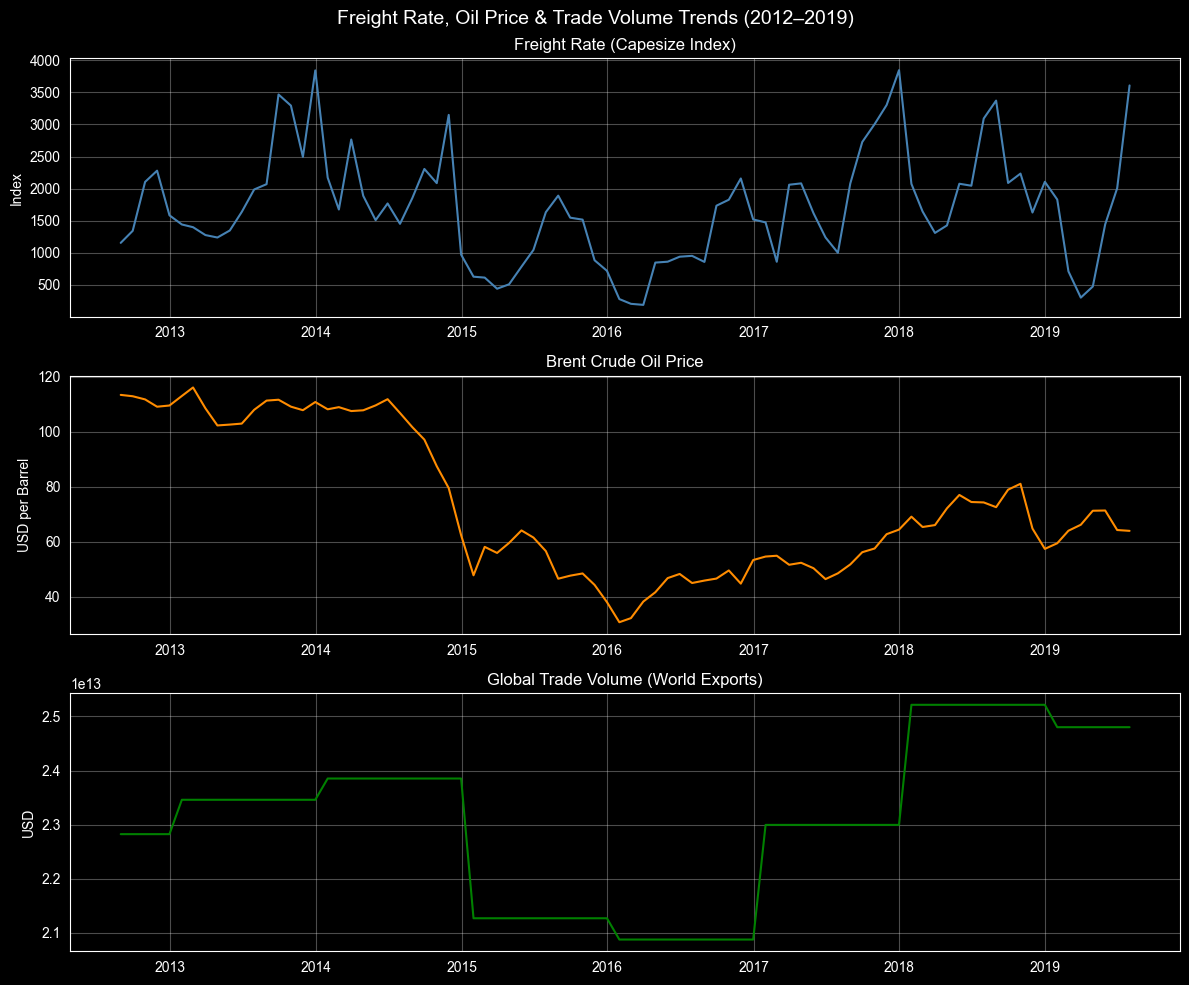

In [11]:
# ── 1. Individual Trend Plots ─────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(12, 10))
fig.suptitle("Freight Rate, Oil Price & Trade Volume Trends (2012–2019)", fontsize=14)

axes[0].plot(df["Date"], df["Freight_Rate"], color="steelblue")
axes[0].set_title("Freight Rate (Capesize Index)")
axes[0].set_ylabel("Index")

axes[1].plot(df["Date"], df["Oil_Price"], color="darkorange")
axes[1].set_title("Brent Crude Oil Price")
axes[1].set_ylabel("USD per Barrel")

axes[2].plot(df["Date"], df["Trade_Volume"], color="green")
axes[2].set_title("Global Trade Volume (World Exports)")
axes[2].set_ylabel("USD")

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/Users/lunga_2.0/freight-analysis/plots/trends.png", dpi=150)
plt.show()

#### Freight Rate (Blue) — Capesize Index
1. 2012–2013: Started low (~1,200), sharp spike to ~2,300 mid-2013, then fell back to ~1,300. Early volatility with no clear direction.
2. 2013–2014: Strong bull run — peaked at ~3,800 in late 2013/early 2014. This was driven by Chinese iron ore import demand, a major driver of Capesize vessels.
3. 2014–2015: Sharp collapse from ~3,500 down to ~500. The worst crash in the dataset. Caused by Chinese economic slowdown and massive oversupply of vessels ordered during the 2010 boom.
4. 2015–2016: Remained deeply depressed — hit the absolute floor of ~250 in early 2016. This was the worst shipping market in decades.
5. 2016–2017: Gradual recovery — climbed from ~250 back to ~1,800. Market slowly rebalancing as old vessels were scrapped.
6. 2017–2019: Volatile recovery with major spikes — peaked at ~3,800 in late 2018 and again rising sharply at end of 2019. New trade activity and tighter vessel supply drove rates up.

### Oil Price (Orange) — Brent Crude

1. **2012–2014: Stable and High**
   Held consistently at approximately **$105–$115 per barrel** for nearly three years. This period reflected tight global supply conditions.

2. **2014–2016: Dramatic Crash**
   Fell from approximately **\$115 in mid-2014** to around **\$33 in early 2016**. This decline was driven by U.S. shale oil flooding the market and OPEC refusing to cut production.

3. **2016–2018: Steady Recovery**
   Climbed from **\$33** back to roughly **\$80** by late 2018 as OPEC production cuts took effect and global demand strengthened.

4. **2018–2019: Moderate Pullback**
   Declined slightly to around **$60–$70**, reflecting demand concerns linked to trade tensions between the United States and China.

#### Global Trade Volume Trend (2012–2019)

1. **2012–2013:** Modest growth from **~\$22.9T** to **~$23.5T**.
   Slow recovery following the 2008 global financial crisis.

2. **2013–2015:** Relatively flat at **~$23.8T**.
   Global trade stagnated as emerging market growth slowed.

3. **2015–2016:** Sharp drop to **~$21.1T** — the largest decline in the dataset.
   Driven by the commodity price collapse, slowdown in China, and a strong U.S. dollar making exports more expensive.

4. **2016–2017:** Partial recovery to **~$23T**.
   Commodity prices stabilized and trade activity improved.

5. **2017–2018:** Strong increase to **~$25T** — the strongest growth period.
   Supported by synchronized global economic expansion and recovering commodity prices.

6. **2018–2019:** Slight pullback to **~$24.8T**.
   Early signs of the U.S.–China trade war began affecting global trade.

##### All three variables tell the same macroeconomic story:

* 2012–2014: Elevated levels — the tail end of the commodity supercycle
* 2015–2016: Simultaneous crash — the global commodity bust hit freight, oil, and trade all at once
* 2017–2019: Recovery — synchronized global growth brought all three back up

This co-movement is exactly what justifies using oil and trade as explanatory variables for freight rates in the regression model.

### Correlation matrix


In [12]:
# ── 2. Correlation Matrix ─────────────────────────────────
print("\n=== Correlation Matrix ===")
print(df[["Freight_Rate", "Oil_Price", "Trade_Volume"]].corr().round(3))


=== Correlation Matrix ===
              Freight_Rate  Oil_Price  Trade_Volume
Freight_Rate         1.000      0.360         0.414
Oil_Price            0.360      1.000         0.459
Trade_Volume         0.414      0.459         1.000


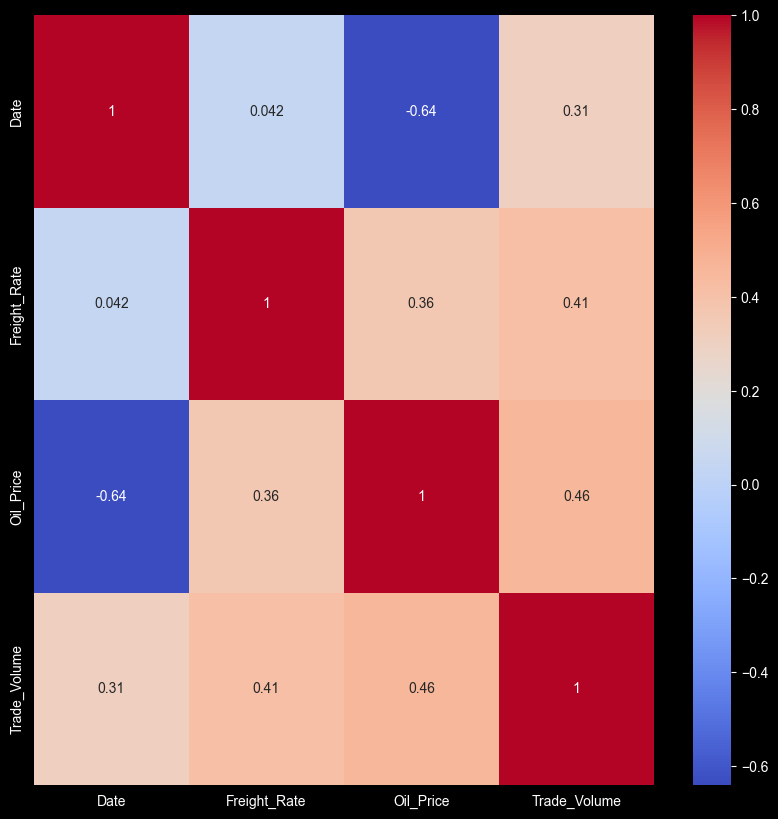

In [16]:
# Plotting the co-relation heatmap
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.show()

#### Explanation

1. Date vs Oil Price: -0.64 (Strong Negative)
This is the most striking finding in the whole matrix. As time progressed from 2012 to 2019, oil prices actually fell overall. This makes perfect sense — oil was at ~**\$110** in 2012 and ended at ~**$65** in 2019, never recovering to its pre-2015 levels. The -0.64 is the oil price crash story captured mathematically.

2. Freight Rate vs Trade Volume: 0.41 (Moderate Positive)
The strongest relationship between your model variables. As global trade grew, shipping demand increased, pushing freight rates up. This confirms trade volume is your best demand-side predictor. The relationship isn't perfect because freight rates also depend on vessel supply, which trade volume doesn't capture.

3. Freight Rate vs Oil Price: 0.36 (Moderate Positive)
When oil prices were high (2012–2014), freight rates were also relatively high. When oil crashed (2015–2016), freight rates crashed too. This confirms oil is a valid cost-side driver. The correlation isn't stronger because oil affects operating costs, not the underlying demand for shipping.

4. Oil Price vs Trade Volume: 0.46 (Moderate Positive)
Oil and trade move together because both are driven by the same underlying force — global economic activity. When the world economy is strong, both trade volumes and energy demand (oil prices) rise together. This co-movement is called multicollinearity— it means oil and trade are not completely independent predictors.

5. Date vs Freight Rate: 0.042 (Nearly Zero)
Freight rates show no overall trend over time — they were just as likely to be high or low in 2012 as in 2019. This confirms freight rates are driven by external forces (oil, trade, supply shocks) rather than simply trending up or down over time. Good news — it means the regression variables are the right ones to explain the movement.

6. Date vs Trade Volume: 0.31 (Weak Positive)
Trade volume grows slowly over time as the global economy expands. The 0.31 reflects long-term globalisation — the world trades slightly more each year on average. It's weak because the 2015–2016 crash temporarily reversed that trend.

##### This Covariant matrix analysis reveals two important things:

* The model variables are justified — both oil (0.36) and trade (0.41) have meaningful positive correlations with freight rates, exactly as economic theory predicts.
* Multicollinearity exists between oil and trade (0.46) — they share common economic drivers, which partially explains why the R² is modest at 0.22. Adding truly independent variables like fleet supply or port congestion indices would improve the model significantly.

### Scatter Plots for the Freight Rate vs the economic drivers

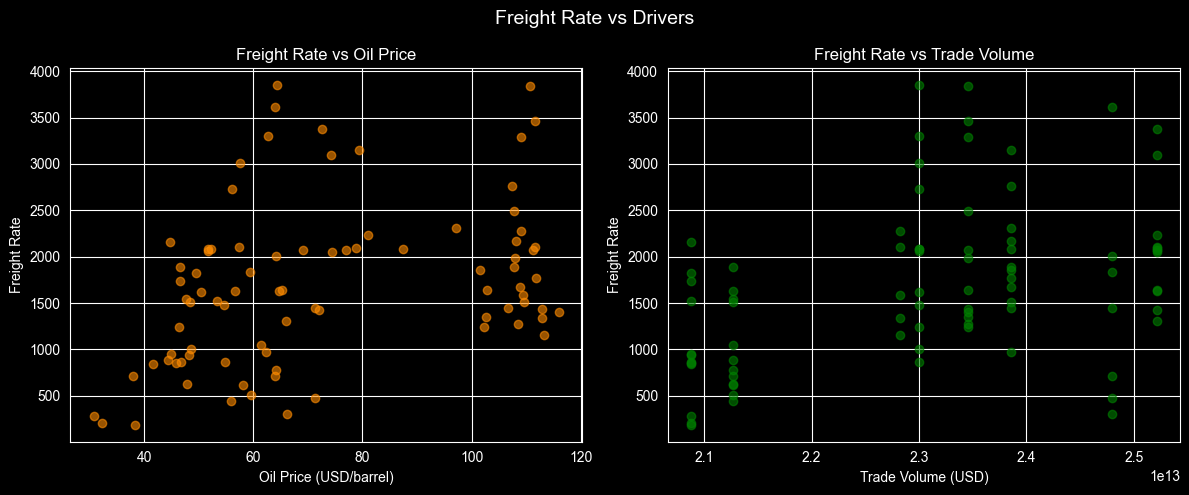

In [18]:
# ── 3. Scatter Plots ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Freight Rate vs Drivers", fontsize=14)

axes[0].scatter(df["Oil_Price"], df["Freight_Rate"], color="darkorange", alpha=0.6)
axes[0].set_xlabel("Oil Price (USD/barrel)")
axes[0].set_ylabel("Freight Rate")
axes[0].set_title("Freight Rate vs Oil Price")

axes[1].scatter(df["Trade_Volume"], df["Freight_Rate"], color="green", alpha=0.6)
axes[1].set_xlabel("Trade Volume (USD)")
axes[1].set_ylabel("Freight Rate")
axes[1].set_title("Freight Rate vs Trade Volume")

plt.tight_layout()
plt.savefig("/Users/lunga_2.0/freight-analysis/plots/scatter.png", dpi=150)
plt.show()

#### Freight Rate vs Oil Price

**Overall pattern:**
There is a loose upward trend. As oil price increases, freight rates tend to increase. This visually confirms the **0.36 correlation** from the heatmap.

---

**$30–$50 range (far left):**
These correspond to the 2015–2016 period when oil prices crashed. Freight rates in this range are mostly between **250–900**, which are the lowest values in the dataset. Both oil prices and freight rates were simultaneously depressed, supporting the commodity bust narrative.

---

**$50–$80 range (middle cluster):**
This is the largest and most dispersed cluster. Freight rates span from approximately **500 to 3,800**. The wide vertical spread indicates that oil price alone is insufficient to predict freight rates in this range. Additional factors contribute significantly to the observed variance.

---

**$100–$120 range (far right):**
These points correspond to the 2012–2014 period of high oil prices. Freight rates cluster between approximately **1,100–2,300**, with a notable outlier around **3,500**. Freight rates are generally higher at elevated oil prices, but substantial scatter remains.

---

The relationship exists but is noisy. The dispersion increases as oil prices rise, indicating that high oil prices are a necessary but not sufficient condition for high freight rates.

#### Freight Rate vs Trade Volume

**Overall pattern:**
The vertical column structure is the most important visual feature. Each column represents one year's trade volume value repeated across 12 months. This occurs due to the forward-fill effect from yearly World Bank trade data.

---

**Column at ~$21.1T (far left, two tight columns)**
These correspond to 2015–2016, the global trade collapse period. Freight rates range from approximately 250 to 2,200, indicating extreme volatility even during the lowest trade volume years.

---

**Column at ~$21.1T (second-left cluster)**
This represents the 2016 market bottom. Freight rates reach their absolute minimum, around 250–300. The combination of the lowest trade volume and low oil prices produced the weakest shipping market in decades.

---

**Columns at ~$23T–$24T (middle clusters)**
These correspond to 2013–2014 and 2017. Freight rates are broadly distributed between roughly 1,000 and 3,800. This reflects a recovering market with intermittent spikes.

---

**Columns at ~$25T (far right)**
These represent 2018–2019, the highest trade volume period. Freight rates range from about 400 to 3,600. Even at peak trade volumes, rates remain volatile due to vessel supply fluctuations.

---

As trade volume increases from left to right, the upper bound of freight rates increases. Higher trade volume allows larger freight rate spikes. However, the wide spread within each column indicates that trade volume determines the ceiling rather than the exact freight rate.

The two plots together reveal the core limitation of the model:

Both oil and trade have real but incomplete relationships with freight rates
* The wide scatter in both plots explains why R² is 0.22 — the two variables capture the direction but not the full magnitude of freight rate movements.
* The missing variables are likely vessel supply (number of ships available), port congestion, and commodity-specific demand, all of which are outside macroeconomic datasets.

### Regression Models


Both models built using scikit-learn LinearRegression.

#### Model 1 — Baseline Model


In [20]:
# ── 4. Regression model ──────────────────────────────────

# ── Features and target ──────────────────────────────────
X = df[["Oil_Price", "Trade_Volume"]]
y = df["Freight_Rate"]

# ── Train model ──────────────────────────────────────────
model = LinearRegression()
model.fit(X, y)

# ── Coefficients ─────────────────────────────────────────
print("=== Regression Results ===")
print(f"Intercept:        {model.intercept_:.2f}")
print(f"β1 Oil Price:     {model.coef_[0]:.4f}")
print(f"β2 Trade Volume:  {model.coef_[1]:.6e}")

# ── Model performance ────────────────────────────────────
df["Predicted"] = model.predict(X)
r2  = r2_score(y, df["Predicted"])
mae = mean_absolute_error(y, df["Predicted"])
print(f"\nR² Score:         {r2:.3f}")
print(f"MAE:              {mae:.2f}")



=== Regression Results ===
Intercept:        -3063.73
β1 Oil Price:     7.1818
β2 Trade Volume:  1.834985e-10

R² Score:         0.208
MAE:              597.65


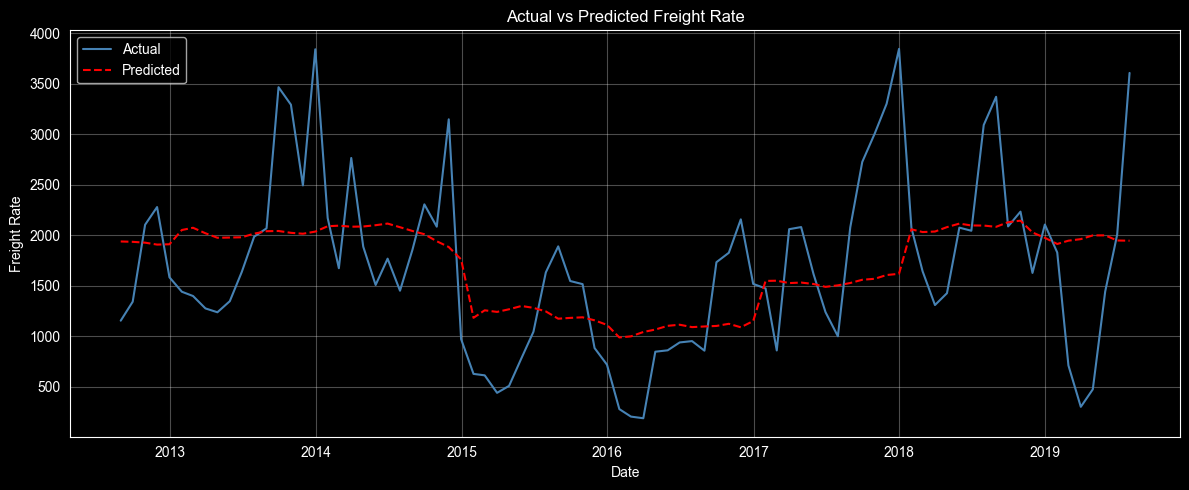

In [21]:
# ── Actual vs Predicted plot ──────────────────────────────
plt.figure(figsize=(12, 5))
plt.plot(df["Date"], df["Freight_Rate"], label="Actual", color="steelblue")
plt.plot(df["Date"], df["Predicted"],   label="Predicted", color="red", linestyle="--")
plt.title("Actual vs Predicted Freight Rate")
plt.ylabel("Freight Rate")
plt.xlabel("Date")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/Users/lunga_2.0/freight-analysis/plots/regression.png", dpi=150)
plt.show()

The baseline model captures the overall trend effectively. The predicted values (red dashed line) follow the general direction of the actual freight rates, showing elevated levels in 2013–2014, a decline in 2015–2016, and a recovery during 2018–2019. However, the model smooths out the sharp spikes observed in the actual data. This behavior is expected for linear regression models, which typically capture broad trends but struggle to represent extreme volatility.

These observations suggest that oil prices and trade volume explain the overall movement in freight rates. The remaining sharp fluctuations are likely driven by additional factors not included in the model, such as geopolitical events, sudden supply disruptions, and short-term market imbalances.

#### Model 2 — Improved model using lagged variables
Shipping does not react to oil price changes instantly — it takes weeks or months for fuel cost changes to flow through to freight rates. Adding lagged variables captures this delay.


In [22]:
# ── Lagged Variables ──────────────────────────────────────
df["Oil_Lag1"] = df["Oil_Price"].shift(1)   # oil price 1 month ago
df["Oil_Lag2"] = df["Oil_Price"].shift(2)   # oil price 2 months ago

# Drop NaN rows created by shifting
df_lag = df.dropna()

# ── Advanced Model ────────────────────────────────────────
X_lag = df_lag[["Oil_Price", "Trade_Volume", "Oil_Lag1", "Oil_Lag2"]]
y_lag = df_lag["Freight_Rate"]

model_lag = LinearRegression()
model_lag.fit(X_lag, y_lag)

# ── Results ───────────────────────────────────────────────
df_lag = df_lag.copy()
df_lag["Predicted_Lag"] = model_lag.predict(X_lag)
r2_lag  = r2_score(y_lag, df_lag["Predicted_Lag"])
mae_lag = mean_absolute_error(y_lag, df_lag["Predicted_Lag"])

print("=== Advanced Model (with Lagged Variables) ===")
print(f"Intercept:        {model_lag.intercept_:.2f}")
print(f"β1 Oil Price:     {model_lag.coef_[0]:.4f}")
print(f"β2 Trade Volume:  {model_lag.coef_[1]:.6e}")
print(f"β3 Oil Lag 1M:    {model_lag.coef_[2]:.4f}")
print(f"β4 Oil Lag 2M:    {model_lag.coef_[3]:.4f}")
print(f"\nR² Score:         {r2_lag:.3f}")
print(f"MAE:              {mae_lag:.2f}")

=== Advanced Model (with Lagged Variables) ===
Intercept:        -2819.86
β1 Oil Price:     8.3209
β2 Trade Volume:  1.691769e-10
β3 Oil Lag 1M:    1.9981
β4 Oil Lag 2M:    -1.6927

R² Score:         0.220
MAE:              598.77


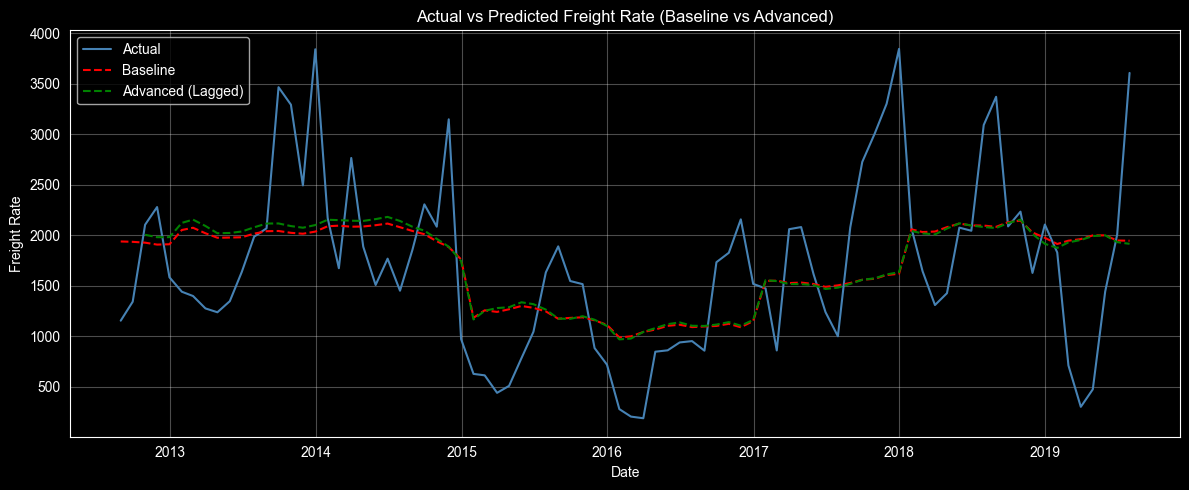

In [23]:
plt.figure(figsize=(12, 5))

# Actual (full)
plt.plot(df["Date"], df["Freight_Rate"],label="Actual", color="steelblue")

# Baseline prediction (full)
plt.plot(df["Date"], df["Predicted"],label="Baseline", color="red", linestyle="--")

# Advanced model prediction (aligned dates)
plt.plot(df_lag["Date"], df_lag["Predicted_Lag"],label="Advanced (Lagged)", color="green", linestyle="--")

plt.title("Actual vs Predicted Freight Rate (Baseline vs Advanced)")
plt.ylabel("Freight Rate")
plt.xlabel("Date")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/Users/lunga_2.0/freight-analysis/plots/regression_advanced.png", dpi=150)
plt.show()

##### Model Comparison

| Model | R² Score | MAE |
|------|---------:|----:|
| Baseline | 0.208 | 597.65 |
| Advanced (with lags) | 0.220 | 598.77 |
| **Improvement** | **+0.012** | — |

##### Interpretation of results

- **β₁ = 7.18** — A $1 increase in oil price is associated with an approximate **7.18-point rise** in the freight rate index.
- **β₂ > 0** — Growth in global trade volume has a **positive effect** on freight rates, reflecting demand-driven pricing.
- **β₃ = +1.99** — The oil price lagged by one month increases freight rates, indicating a **delayed market reaction**.
- **β₄ = −1.69** — The oil price lagged by two months partially reverses the effect, consistent with **short-term mean reversion**.

The **R² = 0.220** indicates that the improved model explains approximately **22% of the variance** in freight rates. While modest, this level of explanatory power is reasonable for freight markets, which are influenced by many volatile external factors.

The remaining unexplained variation is likely driven by variables not included in the model, such as geopolitical developments, fleet supply changes, port congestion, seasonal demand patterns, and unexpected supply shocks.

Overall, the model successfully captures the **broad market trend**, including the decline during 2015–2016 and the recovery observed in 2018–2019.

#### Key Insights

* Freight rates show a moderate positive correlation with both oil prices and global trade volume.
* Changes in oil prices and trade activity help explain the overall directional movement of freight rates.
* Incorporating lagged oil price variables improved model performance, with R² increasing from 0.208 to 0.220, suggesting that shipping markets respond to fuel cost changes with a delay.
* The 2015–2016 shipping downturn is consistently visible across freight rates, oil prices, and global trade volume, indicating synchronized macroeconomic pressure.
* A linear regression model using macroeconomic drivers provides a useful baseline framework for freight rate forecasting, though additional variables may further enhance predictive accuracy.

## Statistical Findings
The analysis of the monthly dataset (Aug 2012 – Jul 2019) led to several critical insights:
* Correlation: Freight rates showed a moderate positive correlation with both oil prices and global trade volume.
* Lagged Market Response: Incorporating lagged oil price variables (1 and 2 months) improved the model's predictive power ($R^2$ increased from 0.208 to 0.220). This indicates that shipping markets respond to fuel cost changes with a temporal delay rather than instantaneously.
* Macroeconomic Pressure: The significant shipping downturn observed in 2015–2016 was reflected across all three variables, highlighting synchronized macroeconomic pressure during that period.

## Conclusion
The multivariate linear regression model establishes that macroeconomic drivers provide a useful baseline framework for forecasting freight rate movements. While fuel costs and trade activity explain the general directional movement of the Baltic Dry Index, the current model accounts for approximately 22% of the variance ($R^2 = 0.22$).